# High-Dimensional Variable Selection in NHANES Health Data

UST-631: Data Preparation and Analysis

## Project Overview

This project examines whether a reduced subset of health-related variables can predict hemoglobin levels nearly as well as a full high-dimensional regression model. Large public health datasets often contain many correlated predictors, which can complicate model interpretation and performance. This analysis investigates the trade-off between predictive accuracy and model simplicity.

The analysis focuses on:

- Variable selection using penalized regression
- Comparison of full and reduced predictive models
- Resampling-based inference using permutation testing and bootstrapping

## Introduction

Hemoglobin concentration is a key indicator of blood health and is routinely measured in large population studies. Modern health datasets often contain many demographic and laboratory variables that are highly correlated, making prediction and interpretation challenging.

In this project, we use data from the **National Health and Nutrition Examination Survey** (NHANES), a nationally representative public health survey conducted by the U.S. Centers for Disease Control and Prevention (CDC). Each observation corresponds to a single participant and includes complete blood count (CBC) measurements alongside demographic information.

The goal of this analysis is to determine whether a reduced subset of health-related variables can predict hemoglobin levels nearly as well as a full model using all available predictors. Because many CBC variables measure related biological processes, strong correlations among predictors are expected. To address this, we use LASSO regression for variable selection, which helps manage multicollinearity.

Model performance is evaluated using test-set mean squared error (MSE). A permutation test is used to compare the full and reduced models, and bootstrap resampling is used to assess variability. Traditional Central Limit Theorem (CLT)–based inference is not used, as the combination of high-dimensional predictors and variable selection can produce non-normal sampling distributions.


## Data Source

The data used in this project are derived from the **National Health and Nutrition Examination Survey (NHANES)**, a public health survey conducted by the U.S. Centers for Disease Control and Prevention (CDC).

The dataset is accessed from the following public repository:
https://github.com/simonaseno/NHANES

## Variables

### Outcome Variable
- **Hemoglobin concentration**, a continuous laboratory measurement obtained
  from complete blood count (CBC) testing.

### Predictor Variables
- **Demographic variables**, including age, sex, and race/ethnicity.
- **CBC laboratory variables** including red and white blood cell counts, hematocrit, mean corpuscular volume, and related measures.

## Research Question and Hypotheses

**Research Question:**  

Can a reduced subset of hematologic and demographic variables predict hemoglobin levels nearly as well as a full model that includes all available predictors?

**Null Hypothesis (H₀):**  
There is no meaningful difference in predictive performance between the reduced and full models. (reduced MSE − full MSE ≤ 0).

**Alternative Hypothesis (H₁):**  
The reduced model performs worse than the full model (reduced MSE − full MSE > 0).

## Methods Overview

A full linear regression model using all predictors was fit to establish baseline performance. A reduced model was then constructed using LASSO for variable selection, accounting for multicollinearity among predictors.

Model performance was evaluated using test-set mean squared error (MSE). A permutation test was used to compare the predictive performance of the full and reduced models, and bootstrap resampling was used to assess variability in model performance.

The Central Limit Theorem was not used because the analysis involves model selection and complex statistics that do not follow a normal sampling distribution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
%matplotlib inline

## Data Preparation

The merged NHANES CBC and demographic dataset was used for analysis. Hemoglobin (LBXHGB) was defined as the outcome variable. Relevant predictors were selected from complete blood count (CBC) measurements and demographic variables. Observations with missing values were removed to ensure complete-case analysis and valid model fitting.


## Variable Definition

Hemoglobin concentration (LBXHGB) was used as the response variable. Predictor variables included clinically relevant CBC measures and demographic characteristics available in the dataset.


In [2]:
health_data = pd.read_csv("cbc_demo_merged_1999_2018.csv")

health_data.shape
health_data.head()
health_data.info()
#health_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 92988 entries, 0 to 92987
Columns: 220 entries, SEQN to DMDHSEDZ
dtypes: float64(207), int64(9), str(4)
memory usage: 156.1 MB


## Variable Selection and Renaming

In [3]:
analysis_data = health_data[
    ["LBXHGB","RIDAGEYR","RIAGENDR","RIDRETH1","LBXRBCSI","LBXHCT","LBXMCVSI","LBXMCHSI","LBXRDW","LBXPLTSI","LBXWBCSI","LBXLYPCT",
     "LBXMOPCT","LBXEOPCT", "LBXBAPCT"]
].copy()

analysis_data = analysis_data.rename(columns={
    "LBXHGB": "hemoglobin",
    "RIDAGEYR": "age",
    "RIAGENDR": "sex",
    "RIDRETH1": "race",

    "LBXRBCSI": "rbc",
    "LBXHCT": "hematocrit",
    "LBXMCVSI": "mcv",
    "LBXMCHSI": "mch",
    "LBXRDW": "rdw",

    "LBXPLTSI": "platelets",

    "LBXWBCSI": "wbc",
    "LBXLYPCT": "lymphocyte_pct",
    "LBXMOPCT": "monocyte_pct",
    "LBXEOPCT": "eosinophil_pct",
    "LBXBAPCT": "basophil_pct"
})

In [4]:
analysis_data.sample(6)

,hemoglobin,age,sex,race,rbc,hematocrit,mcv,mch,rdw,platelets,wbc,lymphocyte_pct,monocyte_pct,eosinophil_pct,basophil_pct
88635,15.3,29,1,3,5.28,43.7,82.7,28.9,13.1,205.0,4.4,42.2,10.9,2.5,1.0
19513,15.3,23,1,1,4.73,43.2,91.2,32.4,12.3,185.0,5.3,23.0,5.6,2.7,0.8
78470,13.6,11,2,3,4.74,39.3,82.9,28.7,12.5,320.0,8.1,44.8,7.5,2.2,0.6
20357,14.3,14,2,3,4.39,40.7,92.6,32.5,11.4,289.0,6.8,34.0,8.3,8.3,0.3
64116,NaN,14,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19755,12.5,27,2,3,3.78,35.5,93.7,33.0,12.5,194.0,6.6,22.7,10.0,1.2,0.8


## Data Cleaning

In [5]:
# Missing data inspection
analysis_data.isnull().mean() * 100

hemoglobin        10.820751
age                0.000000
sex                0.000000
race               0.000000
rbc               10.820751
hematocrit        10.820751
mcv               10.820751
mch               10.820751
rdw               10.820751
platelets         10.822902
wbc               10.823977
lymphocyte_pct    11.016475
monocyte_pct      11.016475
eosinophil_pct    11.016475
basophil_pct      11.016475
dtype: float64

In [6]:
analysis_data_clean = analysis_data.dropna()
analysis_data_clean.isnull().sum()

hemoglobin        0
age               0
sex               0
race              0
rbc               0
hematocrit        0
mcv               0
mch               0
rdw               0
platelets         0
wbc               0
lymphocyte_pct    0
monocyte_pct      0
eosinophil_pct    0
basophil_pct      0
dtype: int64


## Missing Data Inspection

Missing values are concentrated in the complete blood count (CBC) laboratory variables and the hemoglobin outcome, with approximately 10–11% missingness in these measures. In contrast, demographic variables (age, sex, and race) are fully observed. This pattern is consistent with the NHANES study design, where laboratory measurements are collected for a subset of participants rather than missing at random.


## Missing Data Handling

Observations with missing values in the selected variables were removed using complete-case analysis. This approach ensures consistency across predictors and the outcome, resulting in a dataset with no remaining missing values for model fitting.

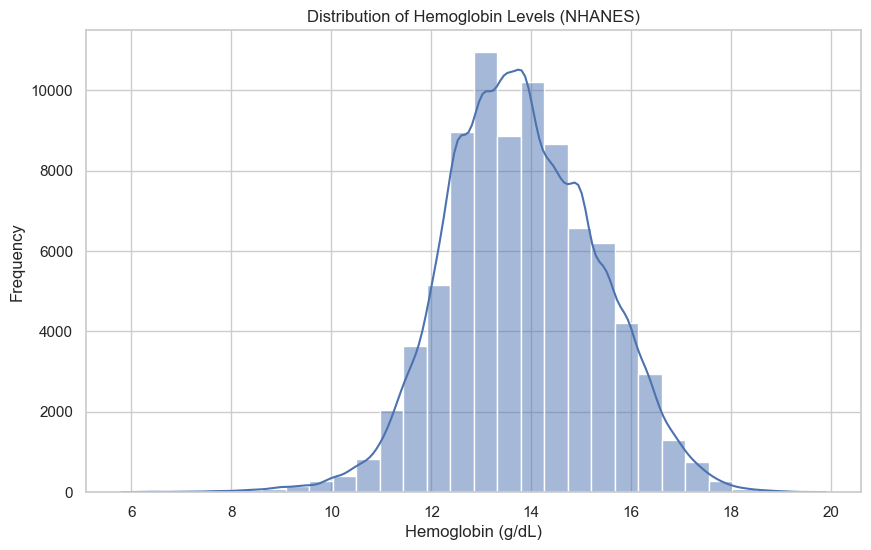

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(analysis_data_clean["hemoglobin"], kde=True,bins=30)
plt.title("Distribution of Hemoglobin Levels (NHANES)")
plt.xlabel("Hemoglobin (g/dL)")
plt.ylabel("Frequency")
plt.show()

The histogram shows that hemoglobin levels are approximately normally distributed, with most values centered around 13 to 14 g/dL. The shape looks fairly symmetric, with no extreme outliers.

## Train–Test Split

The data are split into training (70%) and test (30%) sets, and all preprocessing is performed using only the training data to avoid data leakage

In [8]:
X = analysis_data_clean.drop(columns=["hemoglobin"])
y = analysis_data_clean["hemoglobin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

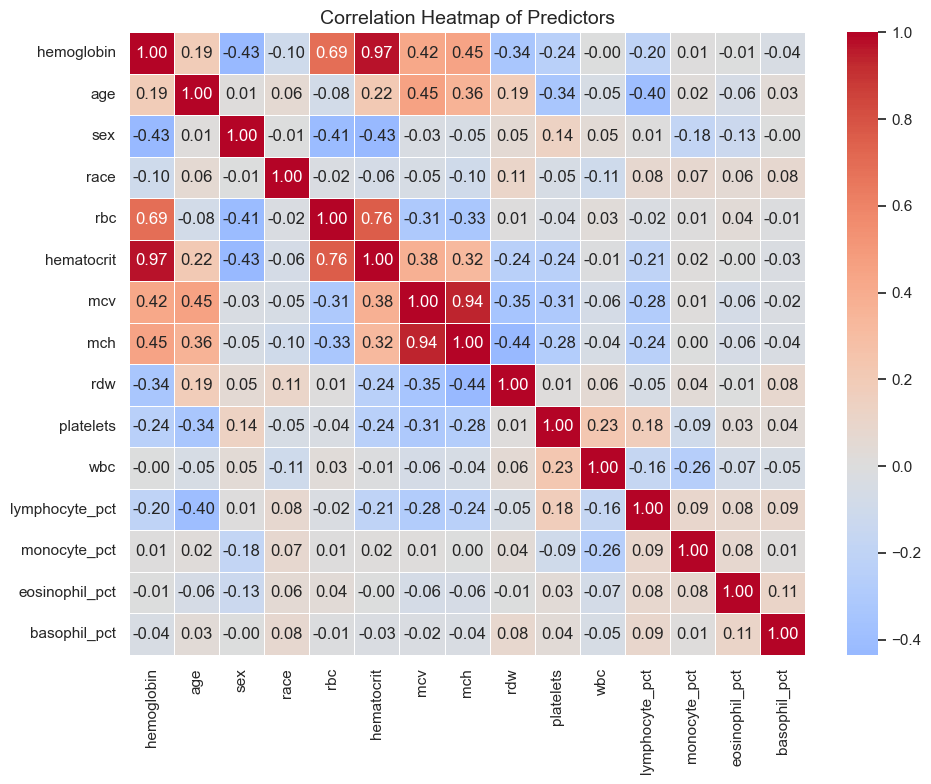

In [9]:
corr_matrix = analysis_data_clean.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,cmap="coolwarm",center=0,annot=True,fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap of Predictors", fontsize=14)
plt.tight_layout()
plt.show()


The heatmap shows substantial correlations among CBC variables, indicating the presence of multicollinearity. This motivates the use of penalized regression methods such as LASSO for variable selection


##  LASSO for Variable Selection 

LASSO regression is used to produce a reduced model by shrinking weaker
predictors’ coefficients to zero.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns)
selected_vars = lasso_coefs[lasso_coefs != 0].index.tolist()

selected_vars


['age', 'sex', 'race', 'hematocrit', 'mcv', 'mch', 'rdw', 'wbc']

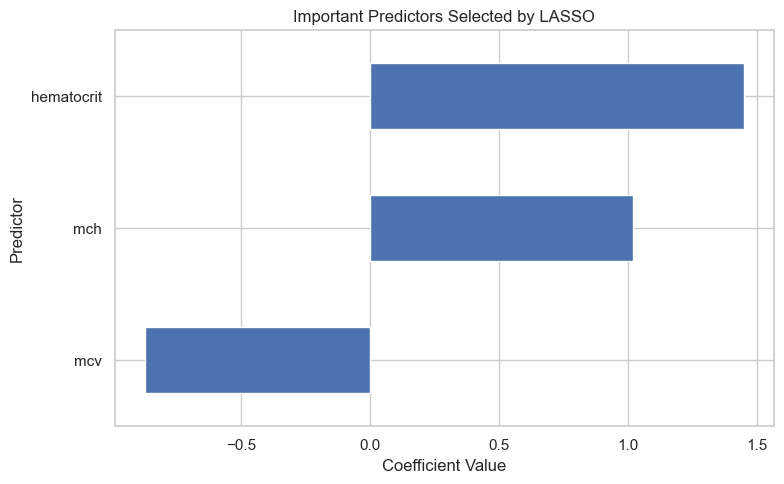

In [11]:
important_coefs = lasso_coefs[np.abs(lasso_coefs) > 0.05]

important_coefs.sort_values().plot(kind="barh",figsize=(8,5))

plt.title("Important Predictors Selected by LASSO")
plt.xlabel("Coefficient Value")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

In [12]:
# All variables selected by LASSO with their coefficients
selected_coefs = lasso_coefs[lasso_coefs != 0]

selected_table = pd.DataFrame({
    "Variable": selected_coefs.index,
    "Coefficient": selected_coefs.values
})

selected_table.sort_values(by="Coefficient")

,Variable,Coefficient
4,mcv,-0.874213
6,rdw,-0.013259
2,race,-0.004939
1,sex,-0.004669
0,age,-0.002188
7,wbc,0.001302
5,mch,1.019818
3,hematocrit,1.451530


## Full Model

A linear regression model using all predictors establishes baseline
predictive performance.

In [13]:
full_model = LinearRegression()
full_model.fit(X_train, y_train)

full_mse = mean_squared_error(
    y_test,
    full_model.predict(X_test)
)


## Reduced Model

In [14]:
reduced_model = LinearRegression()
reduced_model.fit(X_train[selected_vars], y_train)

reduced_mse = mean_squared_error(
    y_test,
    reduced_model.predict(X_test[selected_vars])
)


H0​: reduced MSE − full MSE ≤ 0

In [15]:
observed_difference = reduced_mse - full_mse
full_mse, reduced_mse, observed_difference
print(f"full_mse: {full_mse:.5f} and reduced_mse : {reduced_mse:.5f}")
print()
print(f"Observed difference in MSE (reduced - full): {observed_difference:.5f}")


full_mse: 0.00489 and reduced_mse : 0.00502

Observed difference in MSE (reduced - full): 0.00013


The observed difference in test-set mean squared error (reduced − full) was approximately 0.00013, indicating a minimal increase in prediction error. This suggests that the reduced model achieves performance comparable to the full model despite using fewer predictors.


## Permutation Test

A permutation test evaluates whether the performance difference between
the reduced and full models exceeds what would be expected by chance.

In [16]:
perm_diffs = []

for _ in range(1000):
    y_perm = np.random.permutation(y_train)

    full_model.fit(X_train, y_perm)
    reduced_model.fit(X_train[selected_vars], y_perm)

    mse_f = mean_squared_error(y_test,full_model.predict(X_test))
    mse_r = mean_squared_error(y_test,reduced_model.predict(X_test[selected_vars]))

    perm_diffs.append(mse_r - mse_f)

perm_diffs = np.array(perm_diffs)
p_value = np.mean(perm_diffs >= observed_difference)
p_value
print (f"P-value : {p_value}")


P-value : 0.278


## Permutation Test Conclsuion

The permutation test produced a p-value of 0.278, which exceeds the 0.05 significance level. Therefore, we fail to reject the null hypothesis. This indicates that there is no statistically significant evidence that the reduced model performs worse than the full model.

These results suggest that the reduced model achieves predictive performance comparable to the full model while using fewer predictors, resulting in a simpler and more interpretable model.


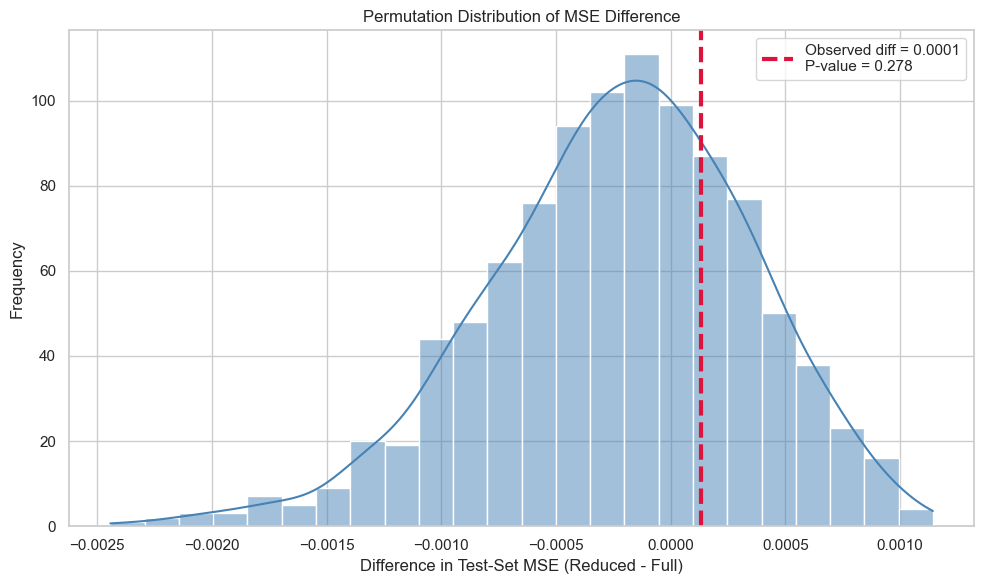

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(perm_diffs,kde=True,color="steelblue",edgecolor="white")
plt.axvline(observed_difference,color="crimson",linestyle="--",linewidth=3,label=f"Observed diff = {observed_difference:.4f}\nP-value = 0.278")
plt.xlabel("Difference in Test-Set MSE (Reduced - Full)")
plt.ylabel("Frequency")
plt.title("Permutation Distribution of MSE Difference")
plt.legend()
plt.tight_layout()
plt.show()


## Bootstrap Confidence Interval for Model Performance

In [19]:
bootstrap_full_mse = []

for _ in range(2000):
    # Resample training data with replacement
    bootstrap_indices = np.random.choice(len(X_train),size=len(X_train), replace=True)
    
    X_train_boot = X_train.iloc[bootstrap_indices]
    y_train_boot = y_train.iloc[bootstrap_indices]

    full_model.fit(X_train_boot, y_train_boot)

    test_predictions = full_model.predict(X_test)

    bootstrap_full_mse.append(mean_squared_error(y_test, test_predictions))


bootstrap_full_mse = np.array(bootstrap_full_mse)
lower_ci, upper_ci = np.quantile(bootstrap_full_mse, [0.025, 0.975])
lower_ci, upper_ci

(np.float64(0.0043852919140348525), np.float64(0.006425783089012267))

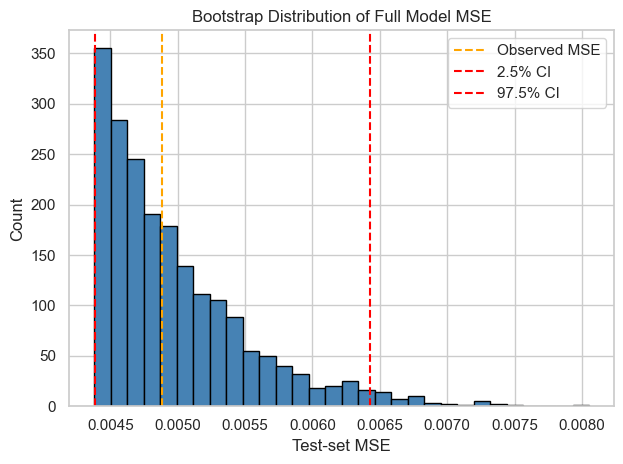

In [20]:
plt.hist(bootstrap_full_mse, bins=30, edgecolor="black",color="steelblue")
plt.axvline(full_mse,color="orange",linestyle="--",label="Observed MSE")
plt.axvline(lower_ci, color="red", linestyle="--", label="2.5% CI")
plt.axvline(upper_ci, color="red", linestyle="--", label="97.5% CI")
plt.xlabel("Test-set MSE")
plt.ylabel("Count")
plt.title("Bootstrap Distribution of Full Model MSE")
plt.legend()
plt.tight_layout()
plt.show()

# Bootstrap Analysis Conclusion
The bootstrap distribution of the full model MSE shows moderate variability, with a 95% confidence interval of approximately [0.00438, 0.00635]. The observed MSE lies well within this interval, indicating that the model’s predictive performance is stable across resampled datasets.
